# Market Sentiment Classification
This notebook contains the experimental version of the project. It will cover:

1. Data loading and checking
2. Data exploration
3. Data preprocessing
4. Train/validation split
5. Feature engineering: BoW, TF-IDF, Word2Vec, Transformer Encoder
6. Classification models and evaluation
7. Final test prediction file generation
   
Labels: **0 = Bearish**, **1 = Bullish**, **2 = Neutral**.

# 1. Data Import

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
import time

#from main_lib_deep import (
#    clean_text, stem_simple, preprocess_lemma, preprocess_stem,
#    set_global_seed, evaluate_classification, print_classification_summary,
#    make_submission, LABEL_NAMES, LABEL_MAP, ID2LABEL, LABEL2ID
#)

from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from gensim.models import Word2Vec
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

import os
import nltk
import torch
import transformers
import tensorflow

pd.set_option("display.max_colwidth", None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
set_global_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
set_global_seed(RANDOM_STATE)

#### =>  auxiliar functions & constants

In [46]:
pd.set_option("display.max_colwidth", None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
set_global_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
set_global_seed(RANDOM_STATE)

important_words = {
    "up", "down", "buy", "sell", "bull", "bear", "bullish", "bearish",
    "profit", "loss", "long", "short", "gain", "gains", "drop", "drops",
    "rally", "rallies", "rise", "rises", "fall", "falls", "low", "high",
    "beat", "miss", "upgrade", "downgrade"
}

stop_words = set(ENGLISH_STOP_WORDS) - important_words

def clean_text(text):
    """Clean a tweet using regular expressions."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)       # remove URLs
    text = re.sub(r"@\w+", " ", text)                            # remove mentions
    text = re.sub(r"#", "", text)                                 # keep hashtag words
    text = re.sub(r"\$([a-zA-Z]+)", r" \1 ", text)               # $AAPL -> AAPL
    text = re.sub(r"[^a-zA-Z\s]", " ", text)                     # remove symbols/numbers
    text = re.sub(r"\s+", " ", text).strip()                     # remove extra spaces
    return text


# Stemming and Lemmatization
lemma = WordNetLemmatizer()
def stem_simple(word):
    """A small fallback stemmer so the notebook runs without extra downloads."""
    for suffix in ['ing','edly','ed','ly','ies','s']:
        if word.endswith(suffix) and len(word) > len(suffix)+3:
            if suffix == "ies":
                return word[:-3] + "y"
            return word[:-len(suffix)]
    return word

def preprocess_lemma(text):
    """Basic cleaning + stopword removal. Used as the main normalized text column."""
    cleaned = clean_text(text)
    tokens = [lemma.lemmatize(w) for w in cleaned.split() if w not in stop_words and len(w)>2]
    return " ".join(tokens)

def preprocess_stem(text):
    cleaned = clean_text(text)
    tokens = [stem_simple(w) for w in cleaned.split() if w not in stop_words and len(w)>2]
    return " ".join(tokens)


# =========================
# Deep Learning utilities
# =========================
# These helpers are intentionally optional: the classic sklearn pipeline still
# runs even when TensorFlow / PyTorch / Transformers are not installed.

LABEL_NAMES = ["Bearish", "Bullish", "Neutral"]
LABEL_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
ID2LABEL = {i: name for i, name in enumerate(LABEL_NAMES)}
LABEL2ID = {name: i for i, name in ID2LABEL.items()}


def set_global_seed(seed=42):
    """Set random seeds for reproducible sklearn / numpy / TF / Torch experiments."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except Exception:
        pass

    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass


def evaluate_classification(y_true, y_pred, model_name, elapsed_seconds=None):
    """Return a dict with the same metrics used throughout the notebook."""
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    accuracy = accuracy_score(y_true, y_pred)

    row = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
    }
    if elapsed_seconds is not None:
        row["Total_evaluation_time"] = elapsed_seconds
    return row


def print_classification_summary(y_true, y_pred):
    """Print a readable classification report using the project label names."""
    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=LABEL_NAMES,
        zero_division=0,
    ))


def make_submission(test_ids, predictions, output_path="submission.csv"):
    """Create the Kaggle/class submission file with columns id,label."""
    submission = pd.DataFrame({"id": test_ids, "label": predictions.astype(int)})
    submission.to_csv(output_path, index=False)
    return submission

In [47]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [48]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (9543, 2)
Test shape: (2388, 2)


,text,label
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0


In [49]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train columns: ['text', 'label']
Test columns: ['id', 'text']


# 2. EDA

In [50]:
train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9543 non-null   str  
 1   label   9543 non-null   int64
dtypes: int64(1), str(1)
memory usage: 955.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 2388 entries, 0 to 2387
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2388 non-null   int64
 1   text    2388 non-null   str  
dtypes: int64(1), str(1)
memory usage: 241.4 KB


In [51]:
print("Missing values in train:")
print(train_df.isnull().sum())
print()

print("Missing values in test:")
print(test_df.isnull().sum())

Missing values in train:
text     0
label    0
dtype: int64

Missing values in test:
id      0
text    0
dtype: int64


In [52]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [53]:
print("Duplicate texts in train:", train_df['text'].duplicated().sum())
print("Duplicate texts in test:", test_df['text'].duplicated().sum())

Duplicate texts in train: 0
Duplicate texts in test: 0


In [54]:
train_df['label'].value_counts().sort_index()

label
0    1442
1    1923
2    6178
Name: count, dtype: int64

In [56]:
train_df[10:20]

,text,label
10,$HOG - Moody's warns on Harley-Davidson https://t.co/LurHBEadeU,0
11,"$HXL - Citing aero ties, Wells slashes PT on Hexcel https://t.co/wU5P2i8WBU",0
12,$I - Intelsat cut to Market Perform at Raymond James https://t.co/YsvsMSQRIb,0
13,$KRG: Compass Point cuts to Sell https://t.co/MCyfTsXc2N,0
14,$LK - Muddy Waters goes short Luckin Coffee https://t.co/8yrbwAjLKG,0
15,$MANT - ManTech downgraded ahead of difficult comps https://t.co/mJ1eSrsFXJ,0
16,$MDCO: Oppenheimer cuts to Perform,0
17,$MPLX $MPC - MPLX cut at Credit Suisse on potential dilution from Marathon strategic review https://t.co/0BFQy4ZU6W,0
18,$MSGN - Imperial downgrades MSG Networks amid sports-free airwaves https://t.co/Ul2S6XNXw8,0
19,$MTLS - Piper hits the Materialise sidelines https://t.co/qlFxZuhkrt,0


In [57]:
label_map = {0:"Bearish", 1:"Bullish", 2:"Neutral"}
train_df['LabelName'] = train_df["label"].map(label_map)
label_table = pd.DataFrame({
    'count': train_df['LabelName'].value_counts(),
    'percentage': (train_df['LabelName'].value_counts(normalize=True) * 100).round(2),
})
display(label_table)

,count,percentage
LabelName,,
Neutral,6178,64.74
Bullish,1923,20.15
Bearish,1442,15.11


## Dependent feature

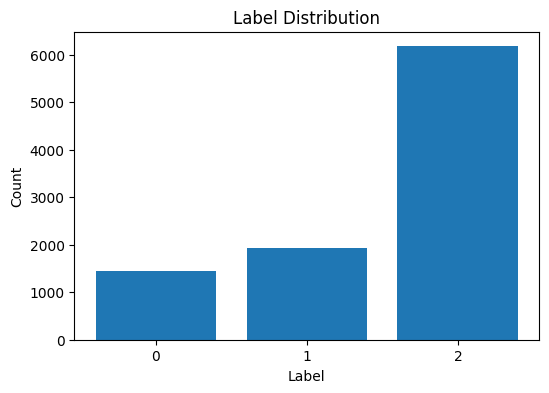

In [59]:
label_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [60]:
train_df["TextLength"] = train_df['text'].astype(str).str.len()
train_df["WordCount"] = train_df['text'].astype(str).apply(lambda x:len(x.split()))
display(train_df[["TextLength","WordCount"]].describe())

display(train_df.groupby('LabelName')[["TextLength","WordCount"]].mean().round(2))

,TextLength,WordCount
count,9543.000000,9543.000000
mean,85.858325,12.178351
std,35.138568,4.665599
min,2.000000,1.000000
25%,58.000000,9.000000
50%,79.000000,11.000000
75%,120.000000,15.000000
max,190.000000,32.000000


,TextLength,WordCount
LabelName,,
Bearish,83.36,12.00
Bullish,80.45,11.93
Neutral,88.13,12.30


In [61]:
train_df

,text,label,LabelName,TextLength,WordCount
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0,Bearish,77,10
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0,Bearish,102,14
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0,Bearish,94,14
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0,Bearish,59,7
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0,Bearish,71,10
...,...,...,...,...,...
9538,The Week's Gainers and Losers on the Stoxx Europe 50 --Dec. 2-6 #economy #MarketScreener https://t.co/iK5MO4NhQq https://t.co/AJh5V5fWTT,2,Neutral,136,16
9539,Tupperware Brands among consumer gainers; Unilever leads the losers,2,Neutral,67,9
9540,vTv Therapeutics leads healthcare gainers; Myomo and Biohaven Pharmaceutical among losers,2,Neutral,89,11
9541,"WORK, XPO, PYX and AMKR among after hour movers",2,Neutral,47,9


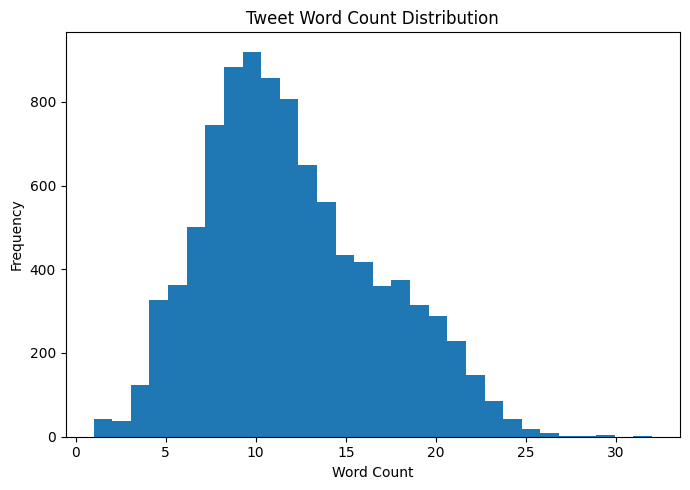

In [62]:
plt.figure(figsize=(7, 5))
train_df["WordCount"].plot(kind="hist", bins=30)
plt.title("Tweet Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Data preprocessing

In [63]:
for df in [train_df, test_df]:
    df['CleanBasic'] = df['text'].apply(clean_text)
    df['CleanLemmatize'] = df['text'].apply(preprocess_lemma)
    df['CleanStmmer'] = df['text'].apply(preprocess_stem)
    df['TextLength'] = df['text'].astype(str).str.len()
    df['TextCount'] = df['text'].astype(str).apply(lambda x: len(str(x).split()))
display(train_df[['text','CleanBasic','CleanLemmatize','CleanStmmer']].head())

,text,CleanBasic,CleanLemmatize,CleanStmmer
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,bynd jpmorgan reels in expectations on beyond meat,bynd jpmorgan reel expectation meat,bynd jpmorgan reel expectation meat
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,ccl rcl nomura points to bookings weakness at carnival and royal caribbean,ccl rcl nomura point booking weakness carnival royal caribbean,ccl rcl nomura point booking weaknes carnival royal caribbean
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",cx cemex cut at credit suisse j p morgan on weak building outlook,cemex cut credit suisse morgan weak building outlook,cemex cut credit suisse morgan weak build outlook
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,ess btig research cuts to neutral,es btig research cut neutral,ess btig research cuts neutral
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,fnko funko slides after piper jaffray pt cut,fnko funko slide piper jaffray cut,fnko funko slide piper jaffray cut


* Lemmatization is used for the final modeling text because it produces cleaner, more meaningful normalized tweets.

,word,frequency
0,stock,1341
1,market,571
2,marketscreener,480
3,new,417
4,report,403
5,price,394
6,say,393
7,result,382
8,earnings,352
9,share,343


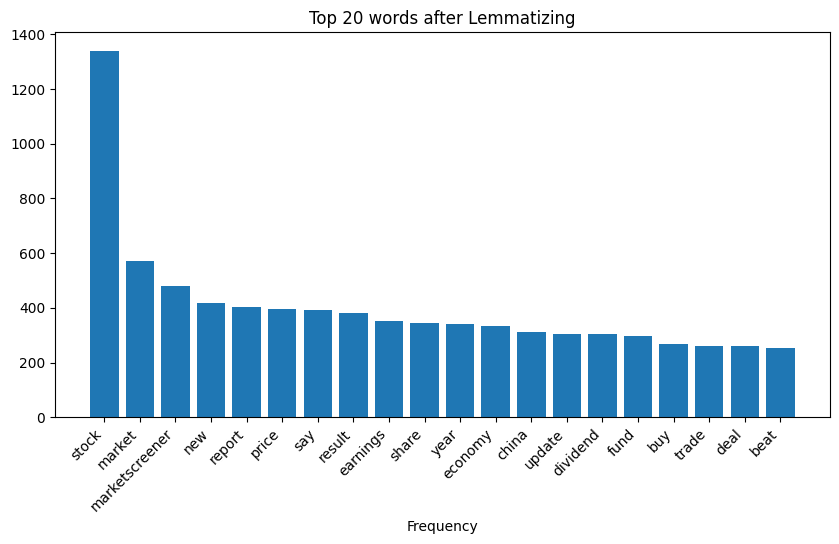

In [64]:

all_words = " ".join(train_df['CleanLemmatize'].fillna("")).split()
top_words = pd.DataFrame(Counter(all_words).most_common(20), columns=['word','frequency'])
display(top_words)
plt.figure(figsize=(10,5))
plt.bar(top_words['word'],top_words['frequency'])
plt.title("Top 20 words after Lemmatizing")
plt.xlabel("Word")
plt.xlabel("Frequency")
plt.xticks(rotation=45,ha='right')
plt.show()

In [66]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df['CleanLemmatize'],
    train_df['label'],
    test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = train_df['label']
)

In [67]:
train_split = pd.DataFrame({
    "text" : train_df.loc[X_train.index,"text"] .values,
    "clean_text" : X_train.values,
    "label" : y_train.values,
})
val_split = pd.DataFrame({
    "text" : train_df.loc[X_val.index,"text"] .values,
    "clean_text" : X_val.values,
    "label" : y_val.values,
})

print("Total training split ",train_split.shape)
print("Total validation split ",val_split.shape)

# Training label distribution
print('Training label distribution :\n', train_split['label'].value_counts(normalize=True).round(3))
print("\n")
print('Validation label distribution :\n', val_split['label'].value_counts(normalize=True).round(3))

Total training split  (7634, 3)
Total validation split  (1909, 3)
Training label distribution :
 label
2    0.647
1    0.201
0    0.151
Name: proportion, dtype: float64


Validation label distribution :
 label
2    0.647
1    0.202
0    0.151
Name: proportion, dtype: float64


# Evaluation model

In [68]:
results = []
reports = {}
predictions = {}
def model_evaluation(name, model, X_trn=None, X_v=None, y_trn=None, y_v=None):
    if X_trn is None:
        X_trn, X_v, y_trn, y_v = X_train, X_val, y_train, y_val

    start = time.time()

    model.fit(X_trn, y_trn)
    pred = model.predict(X_v)

    end_time = time.time() - start

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_v, pred, average="macro", zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_v, pred, average="weighted", zero_division=0
    )

    accuracy = accuracy_score(y_v, pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Total_evaluation_time": end_time
    })
    reports[name] = classification_report(y_v, pred,target_names=['Bearish','Bullish','Neutral'], zero_division=0)
    predictions[name] = pred
    print(f"{name}: accuracy={accuracy:.4f}, macro_f1={macro_f1:.4f},  weighted_f1={weighted_f1:.4f}, end_time={end_time:.2f} ")
    return model

# Feature Engineering and classification models

In [69]:
models = {
    'TF-IDF + logisticRrgression' : Pipeline([
    ("tfidf",TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, max_features=50000)),
    ('clf',OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='liblinear',C=1,class_weight='balanced',random_state=RANDOM_STATE)))
]),
    'TF-IDF + LinearSVC' : Pipeline([
    ("tfidf",TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, max_features=50000)),
    ('clf',LinearSVC(max_iter=3000, dual='auto', C=1,class_weight='balanced',random_state=RANDOM_STATE))
]),
    'TF-IDF word+char + LinearSVC' : Pipeline([
        ('features', FeatureUnion([
            ('word',TfidfVectorizer(analyzer='word',ngram_range=(1,2), min_df=2,sublinear_tf=True, max_features=50000)),
            ('char',TfidfVectorizer(analyzer='char_wb',ngram_range=(2,3), min_df=2,sublinear_tf=True, max_features=50000)),
        ])),
        ('clf',LinearSVC(max_iter=3000, dual='auto', C=0.5,class_weight='balanced',random_state=RANDOM_STATE))
]),
    'TF-TDF + SGDClassifier' : Pipeline([
    ("tfidf",TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, max_features=50000)),
    ('clf',SGDClassifier(loss="modified_huber",alpha=1e-5,max_iter=3000,class_weight='balanced',random_state=RANDOM_STATE))
])
    }
trained_models = {}
for name, model in models.items():
    trained_models[name] = model_evaluation(name,model)


TF-IDF + logisticRrgression: accuracy=0.7994, macro_f1=0.7319,  weighted_f1=0.7994, end_time=0.32 
TF-IDF + LinearSVC: accuracy=0.7988, macro_f1=0.7241,  weighted_f1=0.7963, end_time=0.20 
TF-IDF word+char + LinearSVC: accuracy=0.8025, macro_f1=0.7324,  weighted_f1=0.8004, end_time=0.74 
TF-TDF + SGDClassifier: accuracy=0.7784, macro_f1=0.6985,  weighted_f1=0.7741, end_time=0.21 


# Word2Vec

In [71]:
sentences = [text.split() for text in train_split['clean_text'].fillna("")]
w2v = Word2Vec(
    sentences = sentences,
    window=5,
    vector_size=80,
    min_count=2,
    workers=2,
    sg=1,
    seed = RANDOM_STATE,
    epochs=10
)

def average_word2vec(texts):
    vectors = np.zeros((len(texts), w2v.vector_size), dtype=np.float32)
    for i, text in enumerate(texts):
        token_vectors = [w2v.wv[word] for word in str(text).split() if word in w2v.wv]
        if token_vectors:
            vectors[i] = np.mean(token_vectors, axis=0)
    return vectors
    
X_train_w2v = average_word2vec(train_split['clean_text'])
X_val_w2v = average_word2vec(val_split['clean_text'])

In [27]:
w2v_lr = Pipeline([
    ('scale', StandardScaler()),
    ('clf',LogisticRegression(max_iter=1000, class_weight='balanced',random_state=RANDOM_STATE))
])
model_evaluation("Word2Vec avg + LogisticRegression",w2v_lr,X_train_w2v,X_val_w2v, y_train, y_val)

w2v_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=1,
    max_depth=20
)
model_evaluation("Word2Vec avg + RandomForestClassifier",w2v_rf, X_train_w2v, X_val_w2v, y_train, y_val)

Word2Vec avg + LogisticRegression: accuracy=0.6564, macro_f1=0.5741,  weighted_f1=0.6706, end_time=0.41 
Word2Vec avg + RandomForestClassifier: accuracy=0.7365, macro_f1=0.5794,  weighted_f1=0.7083, end_time=3.18 


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

# Evaluation and analysis

In [72]:
results_df = pd.DataFrame(results).sort_values('Macro F1',ascending=False)
display(results_df)
best_model_name = results_df.iloc[0]['Model']
print("Best validation model: ",best_model_name)
print("----------------------------------------")
print("\nClassification report: ")
print(reports[best_model_name])

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Total_evaluation_time
2,TF-IDF word+char + LinearSVC,0.802514,0.741689,0.724085,0.732359,0.800401,0.737041
0,TF-IDF + logisticRrgression,0.799371,0.731956,0.731966,0.731949,0.799371,0.321414
1,TF-IDF + LinearSVC,0.798848,0.734836,0.714790,0.724132,0.796302,0.200822
3,TF-TDF + SGDClassifier,0.778418,0.715262,0.684944,0.698491,0.774098,0.206801


Best validation model:  TF-IDF word+char + LinearSVC
----------------------------------------

Classification report: 
              precision    recall  f1-score   support

     Bearish       0.64      0.61      0.63       288
     Bullish       0.72      0.67      0.70       385
     Neutral       0.86      0.89      0.87      1236

    accuracy                           0.80      1909
   macro avg       0.74      0.72      0.73      1909
weighted avg       0.80      0.80      0.80      1909



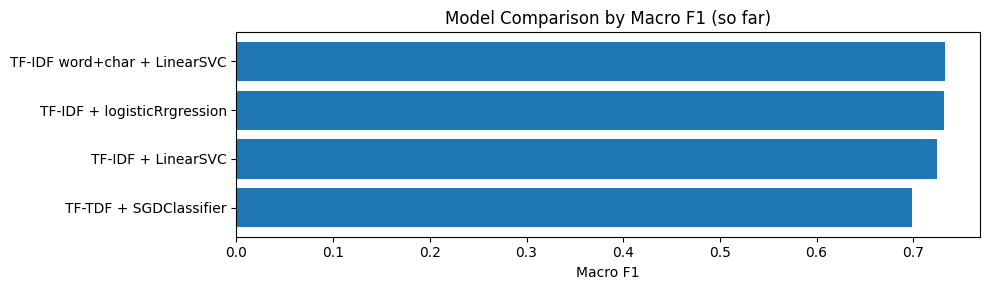

In [74]:
plt.figure(figsize=(10, 3))
plot_df = results_df.sort_values("Macro F1")
plt.barh(plot_df["Model"], plot_df["Macro F1"])
plt.title("Model Comparison by Macro F1 (so far)")
plt.xlabel("Macro F1")
plt.tight_layout()
plt.show()

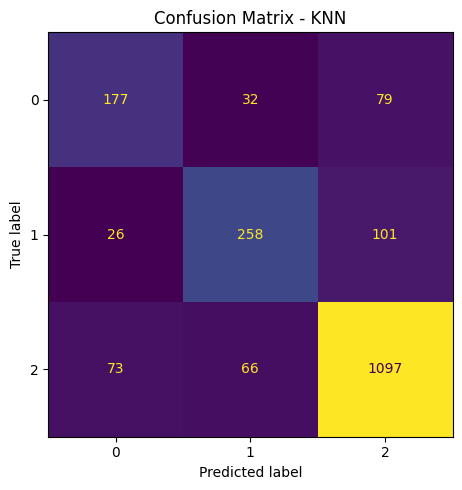

In [75]:
# Compute the confusion matrix
cm = confusion_matrix(y_val, predictions[best_model_name], labels=[0,1,2])

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - KNN")
plt.tight_layout()
plt.show()

____________________________________________________________________


# 8. Deep Learning: LSTM and Transformer Encoders

This section adds neural models to the existing evaluation table:

- **BiLSTM** with an embedding layer trained from scratch.
- **Transformer encoders** using Hugging Face models.
- Suggested encoders:
  - `distilbert-base-uncased`: fast baseline.
  - `bert-base-uncased`: stronger general BERT baseline.
  - `ProsusAI/finbert`: finance-domain BERT, usually very relevant for market sentiment.
  - `roberta-base`: stronger but heavier general encoder.

To avoid accidental long runs, the expensive models use explicit flags.

In [76]:
RUN_LSTM = True 
RUN_TRANSFORMERS = True   # change to True when running in an environment with torch + transformers
RUN_ALL_TRANSFORMERS = False  # False = only first encoder; True = all encoders below

MAX_TOKENS = 30000
MAX_SEQUENCE_LENGTH = 64
BATCH_SIZE = 32
LSTM_EPOCHS = 8
TRANSFORMER_EPOCHS = 3
TRANSFORMER_MAX_LENGTH = 96

TRANSFORMER_ENCODERS = [
    "distilbert-base-uncased",
    "bert-base-uncased",
    "ProsusAI/finbert",
    "roberta-base",
]

print("Train examples:", len(train_split))
print("Validation examples:", len(val_split))

Train examples: 7634
Validation examples: 1909


In [77]:
# Class weights help because this dataset is usually imbalanced.
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2])
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_split["label"].values
)
CLASS_WEIGHTS = {int(c): float(w) for c, w in zip(classes, class_weight_values)}
CLASS_WEIGHTS

{0: 2.2050837666088965, 1: 1.6545296922410055, 2: 0.5149062457844328}

## 8.1 BiLSTM model

Use `text`, not only the heavily cleaned text, because neural models can benefit from cashtags, capitalization patterns and word order.  
The validation split remains exactly the same as the classic models, avoiding data leakage.

In [78]:
if RUN_LSTM:
    try:
        import tensorflow as tf
        from tensorflow.keras import layers, callbacks, models as keras_models

        set_global_seed(RANDOM_STATE)

        vectorizer = layers.TextVectorization(
            max_tokens=MAX_TOKENS,
            output_mode="int",
            output_sequence_length=MAX_SEQUENCE_LENGTH,
            standardize="lower_and_strip_punctuation",
        )

        # Fit tokenizer/vectorizer ONLY on the training split to avoid data leakage.
        vectorizer.adapt(train_split["text"].astype(str).values)

        lstm_model = keras_models.Sequential([
            layers.Input(shape=(), dtype=tf.string),
            vectorizer,
            layers.Embedding(MAX_TOKENS, 128, mask_zero=True),
            layers.SpatialDropout1D(0.20),
            layers.Bidirectional(layers.LSTM(96, return_sequences=True)),
            layers.GlobalMaxPooling1D(),
            layers.Dense(96, activation="relu"),
            layers.Dropout(0.35),
            layers.Dense(3, activation="softmax"),
        ])

        lstm_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )

        early_stop = callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        )

        start = time.time()

        #type object error
        from sklearn.preprocessing import LabelEncoder
        import numpy as np

        X_train_lstm = tf.constant(train_split["text"].fillna("").astype(str).tolist(), dtype=tf.string)
        X_val_lstm = tf.constant(val_split["text"].fillna("").astype(str).tolist(), dtype=tf.string)

        label_encoder = LabelEncoder()
        y_train_lstm = label_encoder.fit_transform(train_split["label"]).astype("int32")
        y_val_lstm = label_encoder.transform(val_split["label"]).astype("int32")               
        
        lstm_history = lstm_model.fit(
            X_train_lstm,
            y_train_lstm,
            validation_data=(X_val_lstm, y_val_lstm),
            epochs=LSTM_EPOCHS,
            batch_size=BATCH_SIZE,
            class_weight=CLASS_WEIGHTS,
            callbacks=[early_stop],
            verbose=1,
        )
        
        lstm_pred_proba = lstm_model.predict(X_val_lstm, batch_size=BATCH_SIZE)
        lstm_pred = np.argmax(lstm_pred_proba, axis=1)
        elapsed = time.time() - start

        print(classification_report(
            y_val_lstm,
            lstm_pred,
            target_names=label_encoder.classes_.astype(str)
        ))

        row = evaluate_classification(y_val_lstm, lstm_pred, "BiLSTM Embedding", elapsed)

        reports["BiLSTM Embedding"] = classification_report(
            y_val_lstm,
            lstm_pred,
            target_names=label_encoder.classes_.astype(str),
            zero_division=0
        )
        
        predictions["BiLSTM Embedding"] = lstm_pred
        trained_models["BiLSTM Embedding"] = lstm_model

        print(f"BiLSTM Embedding: accuracy={row['Accuracy']:.4f}, macro_f1={row['Macro F1']:.4f}, weighted_f1={row['Weighted F1']:.4f}")
        print(reports["BiLSTM Embedding"])

    except ImportError as e:
        print("TensorFlow is not installed. Install it with: pip install tensorflow")
        print(e)
else:
    print("RUN_LSTM=False, skipping BiLSTM.")

c:\Users\antor\.conda\envs\textmining\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/8


c:\Users\antor\.conda\envs\textmining\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


239/239 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.6163 - loss: 0.8596 - val_accuracy: 0.7810 - val_loss: 0.5983
Epoch 2/8
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.8864 - loss: 0.3382 - val_accuracy: 0.7690 - val_loss: 0.6707
Epoch 3/8
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9663 - loss: 0.1137 - val_accuracy: 0.7643 - val_loss: 0.8115
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.54      0.62      0.58       288
           1       0.69      0.69      0.69       385
           2       0.88      0.85      0.86      1236

    accuracy                           0.78      1909
   macro avg       0.70      0.72      0.71      1909
weighted avg       0.79      0.78      0.78      1909

BiLSTM Embedding: accuracy=0.7810, macro_f1=0.7104, weighted_f1=0.7845
              precision    recall  f1-score   support

           0       0.54      0.62      0.58       288
           1       0.69 

,accuracy,loss,val_accuracy,val_loss
0,0.616322,0.859599,0.781037,0.598297
1,0.886429,0.338184,0.768989,0.670716
2,0.966335,0.113709,0.764274,0.811488


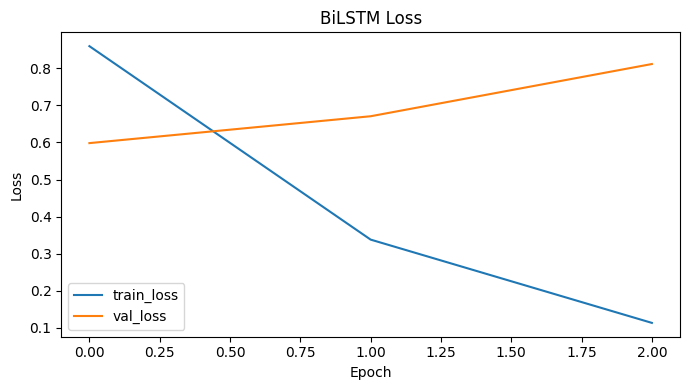

In [79]:
if RUN_LSTM and "lstm_history" in globals():
    history_df = pd.DataFrame(lstm_history.history)
    display(history_df)

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["loss"], label="train_loss")
    plt.plot(history_df["val_loss"], label="val_loss")
    plt.title("BiLSTM Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

The BiLSTM model exhibited signs of overfitting after the first epochs, as the training loss continuously decreased while validation loss increased. This suggests the model memorized training patterns without improving generalization performance.

## 8.2 Transformer encoder fine-tuning

This uses the Hugging Face `Trainer`. Start with `distilbert-base-uncased`; after it works, enable the full list.  
For this project, `ProsusAI/finbert` is especially important because the corpus is financial/market sentiment.

In [80]:
def run_transformer_encoder(model_name, train_split, val_split, epochs=3, max_length=96, batch_size=16):
    import time
    import numpy as np
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        DataCollatorWithPadding,
    )

    set_global_seed(RANDOM_STATE)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_ds = Dataset.from_pandas(
        train_split[["text", "label"]].rename(columns={"label": "labels"}),
        preserve_index=False,
    )
    val_ds = Dataset.from_pandas(
        val_split[["text", "label"]].rename(columns={"label": "labels"}),
        preserve_index=False,
    )

    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_length)

    train_ds = train_ds.map(tokenize_batch, batched=True)
    val_ds = val_ds.map(tokenize_batch, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        metrics = evaluate_classification(labels, preds, model_name)
        return {
            "accuracy": metrics["Accuracy"],
            "macro_f1": metrics["Macro F1"],
            "weighted_f1": metrics["Weighted F1"],
            "macro_precision": metrics["Macro Precision"],
            "macro_recall": metrics["Macro Recall"],
        }

    training_kwargs = dict(
        output_dir=f"./transformer_runs/{model_name.replace('/', '_')}",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        report_to="none",
        seed=RANDOM_STATE,
    )

    try:
        training_args = TrainingArguments(eval_strategy="epoch", **training_kwargs)
    except TypeError:
        training_args = TrainingArguments(evaluation_strategy="epoch", **training_kwargs)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        #tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    pred_output = trainer.predict(val_ds)
    pred = np.argmax(pred_output.predictions, axis=1)
    elapsed = time.time() - start

    row = evaluate_classification(y_val, pred, f"Transformer: {model_name}", elapsed)
    report = classification_report(y_val, pred, target_names=LABEL_NAMES, zero_division=0)

    return {
        "model_name": model_name,
        "trainer": trainer,
        "tokenizer": tokenizer,
        "pred": pred,
        "row": row,
        "report": report,
    }

In [81]:
transformer_artifacts = {}

if RUN_TRANSFORMERS:
    try:
        encoders_to_run = TRANSFORMER_ENCODERS if RUN_ALL_TRANSFORMERS else TRANSFORMER_ENCODERS[:1]

        for encoder_name in encoders_to_run:
            print("\n" + "=" * 80)
            print("Fine-tuning:", encoder_name)
            artifact = run_transformer_encoder(
                encoder_name,
                train_split=train_split,
                val_split=val_split,
                epochs=TRANSFORMER_EPOCHS,
                max_length=TRANSFORMER_MAX_LENGTH,
                batch_size=16,
            )

            model_label = f"Transformer: {encoder_name}"
            transformer_artifacts[model_label] = artifact
            results.append(artifact["row"])
            reports[model_label] = artifact["report"]
            predictions[model_label] = artifact["pred"]
            trained_models[model_label] = artifact["trainer"]

            print(f"{model_label}: accuracy={artifact['row']['Accuracy']:.4f}, macro_f1={artifact['row']['Macro F1']:.4f}, weighted_f1={artifact['row']['Weighted F1']:.4f}")
            print(artifact["report"])

    except ImportError as e:
       print("Missing deep learning dependencies.")
       print("Install with: pip install torch transformers datasets accelerate evaluate")
       print(e)
else:
    print("RUN_TRANSFORMERS=False, skipping Transformer fine-tuning.")


Fine-tuning: distilbert-base-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3450.94it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\antor\.conda\envs\textmining\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no a

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.574655,0.440413,0.842850,0.782718,0.838233,0.815177,0.758471
2,0.317678,0.402217,0.860660,0.814047,0.859120,0.826797,0.802708
3,0.201839,0.432743,0.864851,0.821859,0.863568,0.832816,0.811967


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.82it/s]
c:\Users\antor\.conda\envs\textmining\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.09it/s]
c:\Users\antor\.conda\envs\textmining\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.38it/s]
c:\Users\antor\.conda\envs\textmining\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Transformer: distilbert-base-uncased: accuracy=0.8649, macro_f1=0.8219, weighted_f1=0.8636
              precision    recall  f1-score   support

     Bearish       0.78      0.75      0.76       288
     Bullish       0.82      0.77      0.79       385
     Neutral       0.89      0.92      0.91      1236

    accuracy                           0.86      1909
   macro avg       0.83      0.81      0.82      1909
weighted avg       0.86      0.86      0.86      1909



## 8.3 Consolidated comparison

In [82]:
results_df = pd.DataFrame(results).drop_duplicates(subset=["Model"], keep="last").sort_values("Macro F1", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print("Best validation model:", best_model_name)
print("\nClassification report:")
print(reports[best_model_name])

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Total_evaluation_time
4,Transformer: distilbert-base-uncased,0.864851,0.832816,0.811967,0.821859,0.863568,2168.978974
2,TF-IDF word+char + LinearSVC,0.802514,0.741689,0.724085,0.732359,0.800401,0.737041
0,TF-IDF + logisticRrgression,0.799371,0.731956,0.731966,0.731949,0.799371,0.321414
1,TF-IDF + LinearSVC,0.798848,0.734836,0.714790,0.724132,0.796302,0.200822
3,TF-TDF + SGDClassifier,0.778418,0.715262,0.684944,0.698491,0.774098,0.206801


Best validation model: Transformer: distilbert-base-uncased

Classification report:
              precision    recall  f1-score   support

     Bearish       0.78      0.75      0.76       288
     Bullish       0.82      0.77      0.79       385
     Neutral       0.89      0.92      0.91      1236

    accuracy                           0.86      1909
   macro avg       0.83      0.81      0.82      1909
weighted avg       0.86      0.86      0.86      1909



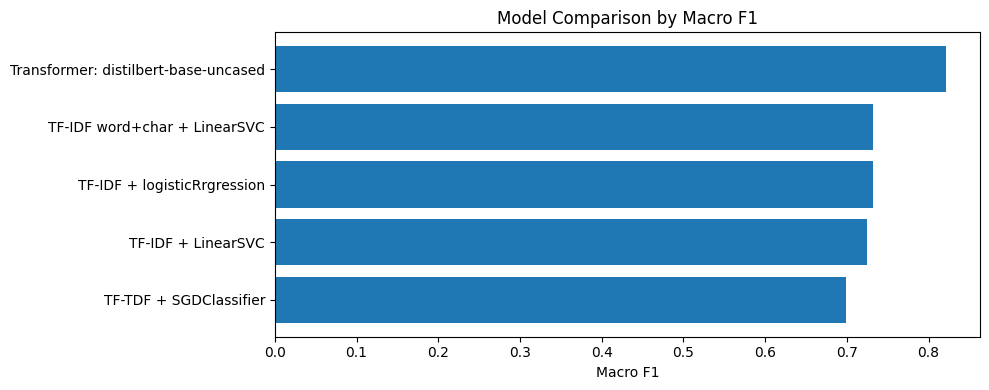

In [83]:
plt.figure(figsize=(10, max(4, 0.35 * len(results_df))))
plot_df = results_df.sort_values("Macro F1")
plt.barh(plot_df["Model"], plot_df["Macro F1"])
plt.title("Model Comparison by Macro F1")
plt.xlabel("Macro F1")
plt.tight_layout()
plt.show()

## 8.4 Test prediction generation

This creates predictions for the test set from the best available model.  
For Transformers, it uses the selected `Trainer`; for the BiLSTM, it uses the Keras model; for sklearn models, it uses the existing pipeline.

In [84]:
def predict_test_with_best_model(best_model_name):
    if best_model_name.startswith("Transformer:"):
        artifact = transformer_artifacts[best_model_name]
        trainer = artifact["trainer"]
        tokenizer = artifact["tokenizer"]        

        from datasets import Dataset
        test_ds = Dataset.from_pandas(
            test_df[["text"]].copy(),
            preserve_index=False,
        )

        def tokenize_batch(batch):
            return tokenizer(batch["text"], truncation=True, max_length=TRANSFORMER_MAX_LENGTH)

        test_ds = test_ds.map(tokenize_batch, batched=True)
        pred_output = trainer.predict(test_ds)
        return np.argmax(pred_output.predictions, axis=1)

    if best_model_name == "BiLSTM Embedding":
        probs = trained_models[best_model_name].predict(test_df["text"].astype(str).values, batch_size=BATCH_SIZE)
        return np.argmax(probs, axis=1)

    # sklearn/Word2Vec baselines
    model = trained_models[best_model_name]

    if best_model_name.startswith("Word2Vec"):
        X_test_w2v = average_word2vec(test_df["CleanLemmatize"].fillna(""))
        return model.predict(X_test_w2v)

    return model.predict(test_df["CleanLemmatize"].fillna(""))

test_predictions = predict_test_with_best_model(best_model_name)
submission = make_submission(test_df["id"].values, test_predictions, output_path="submission.csv")
display(submission.head())
print("Saved: submission.csv")

Map: 100%|██████████| 2388/2388 [00:00<00:00, 26688.62 examples/s]
c:\Users\antor\.conda\envs\textmining\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,id,label
0,0,1
1,1,2
2,2,2
3,3,2
4,4,2


Saved: submission.csv
